# CS 229 - HW1 EC2: Confidence Calibration

Examine the confidence calibration of all methods. Compute `p(final answer | prompt, output reasoning)` for each prediction using a forward pass on the generated output. Build a reliability diagram and compute Expected Calibration Error (ECE) as in [Guo et al., 2017](https://arxiv.org/abs/1706.04599).


## Setup


In [1]:
# !pip install -q transformers torch peft accelerate tqdm


In [2]:
import torch, re, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
LORA_PATH = "drive/MyDrive/lora_alien_calcgpt"  # adjust path as needed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map="auto")
print(f"Loaded {MODEL_NAME}")

# Load LoRA fine-tuned model
lora_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map="auto")
lora_model = PeftModel.from_pretrained(lora_model, LORA_PATH)
lora_model.eval()
print(f"Loaded LoRA adapter from {LORA_PATH}")


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded Qwen/Qwen2.5-0.5B-Instruct


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

ValueError: Can't find 'adapter_config.json' at 'drive/MyDrive/lora_alien_calcgpt'

## Load Data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
data = torch.load('drive/MyDrive/HW 1 Alien CalcGPT.pt', weights_only=False)


In [ ]:
# data = torch.load('hw1_data.pt', weights_only=False)
train_problems  = data['train_problems']
train_answers   = data['train_answers']
train_levels    = data['train_levels']
test_problems   = data['test_problems']
test_answers    = data['test_answers']
test_levels     = data['test_levels']
test_standard   = data['test_standard']
operators       = data['operators']
print(f"Train: {len(train_problems)}, Test: {len(test_problems)}")


Train: 300, Test: 150


## Helpers


In [ ]:
def generate_response(messages, model, tokenizer, max_new_tokens=64):
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True), output_ids[0]

def extract_answer(response):
    match = re.search(r"Final Answer:\s*(-?\d+)", response)
    return int(match.group(1)) if match else None


## Confidence Extraction

For each prediction, we do a forward pass on the full (prompt + generated) sequence and extract the probability the model assigns to each answer token at the position where it was generated.


In [ ]:
@torch.no_grad()
def get_answer_confidence(model, tokenizer, full_ids, response_text):
    """Get the model's confidence in its final answer tokens.
    
    Computes P(answer) as product of per-token probabilities.
    Also computes restricted-set confidence: P(answer=pred | answer in {0..500}).
    """
    match = re.search(r"Final Answer:\s*(-?\d+)", response_text)
    if match is None:
        return None, None, None
    
    answer_str = match.group(1)
    pred = int(answer_str)
    
    # Forward pass to get logits for all positions
    logits = model(full_ids.unsqueeze(0)).logits[0]  # (seq_len, vocab_size)
    probs = torch.softmax(logits, dim=-1)
    
    # Tokenize the answer digits to find their token ids
    answer_token_ids = tokenizer.encode(answer_str, add_special_tokens=False)
    
    # Find last occurrence in the full sequence
    full_list = full_ids.tolist()
    ans_start = -1
    for i in range(len(full_list) - len(answer_token_ids), -1, -1):
        if full_list[i:i+len(answer_token_ids)] == answer_token_ids:
            ans_start = i
            break
    
    if ans_start == -1:
        return pred, 0.0, 0.0
    
    # Raw confidence = product of P(token_t | tokens_{<t}) for answer tokens
    token_probs = []
    for k, tok_id in enumerate(answer_token_ids):
        pos = ans_start + k - 1
        if pos >= 0 and pos < probs.shape[0]:
            token_probs.append(probs[pos, tok_id].item())
    
    raw_confidence = np.prod(token_probs) if token_probs else 0.0
    
    # Restricted answer set normalization: P(answer = i) for i in 0..500
    # Use the first answer-token position's logits as a proxy.
    # For each candidate integer, tokenize it and use P(first_token) as its score.
    first_pos = ans_start - 1  # position whose logits predict first answer token
    if first_pos >= 0 and first_pos < probs.shape[0]:
        first_token_probs = probs[first_pos]  # (vocab_size,)
        
        restricted_probs = {}
        for candidate in range(501):
            cand_str = str(candidate)
            cand_tokens = tokenizer.encode(cand_str, add_special_tokens=False)
            first_tok = cand_tokens[0]
            restricted_probs[candidate] = first_token_probs[first_tok].item()
        
        total = sum(restricted_probs.values())
        if total > 0 and pred in restricted_probs:
            restricted_confidence = restricted_probs[pred] / total
        else:
            restricted_confidence = raw_confidence
    else:
        restricted_confidence = raw_confidence
    
    return pred, raw_confidence, restricted_confidence


## Prompt Builders


In [ ]:
def build_base_prompt(problem):
    return [{'role': "user", 'content': f"What is {problem}? Respond with: Final Answer: <number>"}]

def build_system_prompt(problem):
    sys = "You are an expert mathematician who understands the following alien operators:\n"
    for name, desc in operators.items():
        sys += f"- {name}(...) = {desc}\n"
    return [{'role': "system", 'content': sys}, {'role': "user", 'content': f"What is {problem}? Respond with: Final Answer: <number>"}]

def build_cot_prompt(problem):
    sys = "You are an expert mathematician who understands the following alien operators:\n"
    for name, desc in operators.items():
        sys += f"- {name}(...) = {desc}\n"
    sys += "Explain your reasoning step-by-step. You MUST conclude with: 'Final Answer: <number>'.\n"
    return [{'role': "system", 'content': sys}, {'role': "user", 'content': f"What is {problem}? Show your work. End with: Final Answer: <number>"}]

# --- ICL ---
def get_icl_examples(train_problems, train_answers, train_levels, n_per_level=1):
    res = []
    for difficulty in [1, 2, 3]:
        idxs = [i for i in range(len(train_problems)) if train_levels[i].item() == difficulty]
        for i in idxs[:n_per_level]:
            res.append((train_problems[i], train_answers[i].item()))
    return res

icl_examples = get_icl_examples(train_problems, train_answers, train_levels, n_per_level=1)

def build_icl_prompt(problem):
    sys = "You are an expert mathematician who understands the following alien operators:\n"
    for name, desc in operators.items():
        sys += f"- {name}(...) = {desc}\n"
    messages = [{"role": "system", "content": sys}]
    for ex_prob, ex_ans in icl_examples:
        messages.append({"role": "user", "content": f"What is {ex_prob}? Respond with: Final Answer: <number>"})
        messages.append({"role": "assistant", "content": f"Final Answer: {ex_ans}"})
    messages.append({"role": "user", "content": f"What is {problem}? Respond with: Final Answer: <number>"})
    return messages

# (prompt_fn, max_tokens, model_to_use)
methods = {
    "Base": (build_base_prompt, 64, model),
    "System": (build_system_prompt, 64, model),
    "CoT": (build_cot_prompt, 512, model),
    "ICL": (build_icl_prompt, 64, model),
    "LoRA": (build_system_prompt, 64, lora_model),
}


## Run Calibration Experiment


In [ ]:
calibration_results = {}

for method_name, (prompt_fn, max_tokens, method_model) in methods.items():
    print(f"\n{'='*50}\nMethod: {method_name}\n{'='*50}")
    
    preds, raw_confs, restricted_confs, corrects = [], [], [], []
    for i, problem in enumerate(tqdm(test_problems, desc=method_name)):
        response, full_ids = generate_response(prompt_fn(problem), method_model, tokenizer, max_tokens)
        pred, raw_conf, rest_conf = get_answer_confidence(method_model, tokenizer, full_ids, response)
        
        if pred is not None and raw_conf is not None:
            preds.append(pred)
            raw_confs.append(raw_conf)
            restricted_confs.append(rest_conf)
            corrects.append(pred == test_answers[i].item())
    
    calibration_results[method_name] = {
        "predictions": preds,
        "raw_confidences": np.array(raw_confs),
        "restricted_confidences": np.array(restricted_confs),
        "corrects": np.array(corrects),
    }
    
    acc = np.mean(corrects) if corrects else 0
    print(f"  Accuracy: {acc:.3f} ({sum(corrects)}/{len(corrects)})")
    print(f"  Avg raw confidence: {np.mean(raw_confs):.4f}")
    print(f"  Avg restricted confidence: {np.mean(restricted_confs):.4f}")
    print(f"  Skipped (format failures): {len(test_problems) - len(preds)}")



Method: Base


Base: 100%|██████████| 150/150 [00:12<00:00, 11.72it/s]


  Accuracy: 0.053 (8/150)
  Avg raw confidence: 0.2870
  Avg restricted confidence: 0.0061
  Skipped (format failures): 0

Method: System


System: 100%|██████████| 150/150 [00:10<00:00, 14.36it/s]


  Accuracy: 0.116 (17/147)
  Avg raw confidence: 0.4747
  Avg restricted confidence: 0.0140
  Skipped (format failures): 3

Method: CoT


CoT: 100%|██████████| 150/150 [03:03<00:00,  1.22s/it]

  Accuracy: 0.201 (29/144)
  Avg raw confidence: 0.9235
  Avg restricted confidence: 0.0879
  Skipped (format failures): 6


## Reliability Diagram & ECE


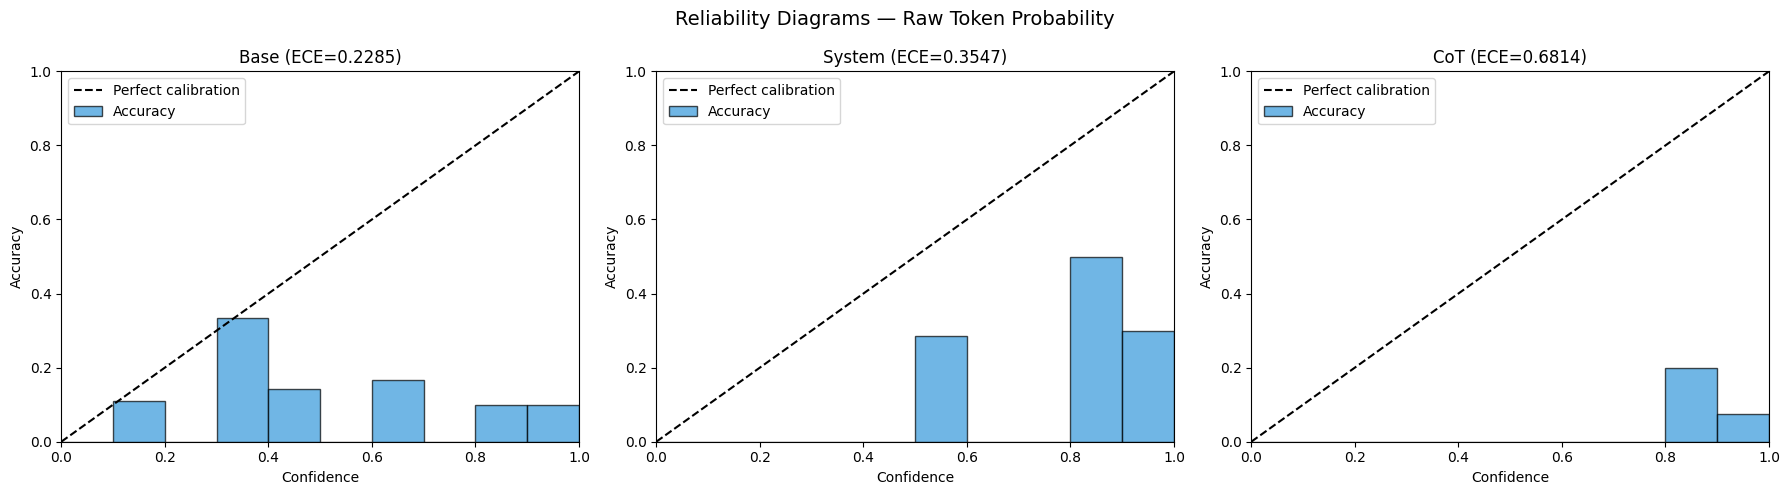

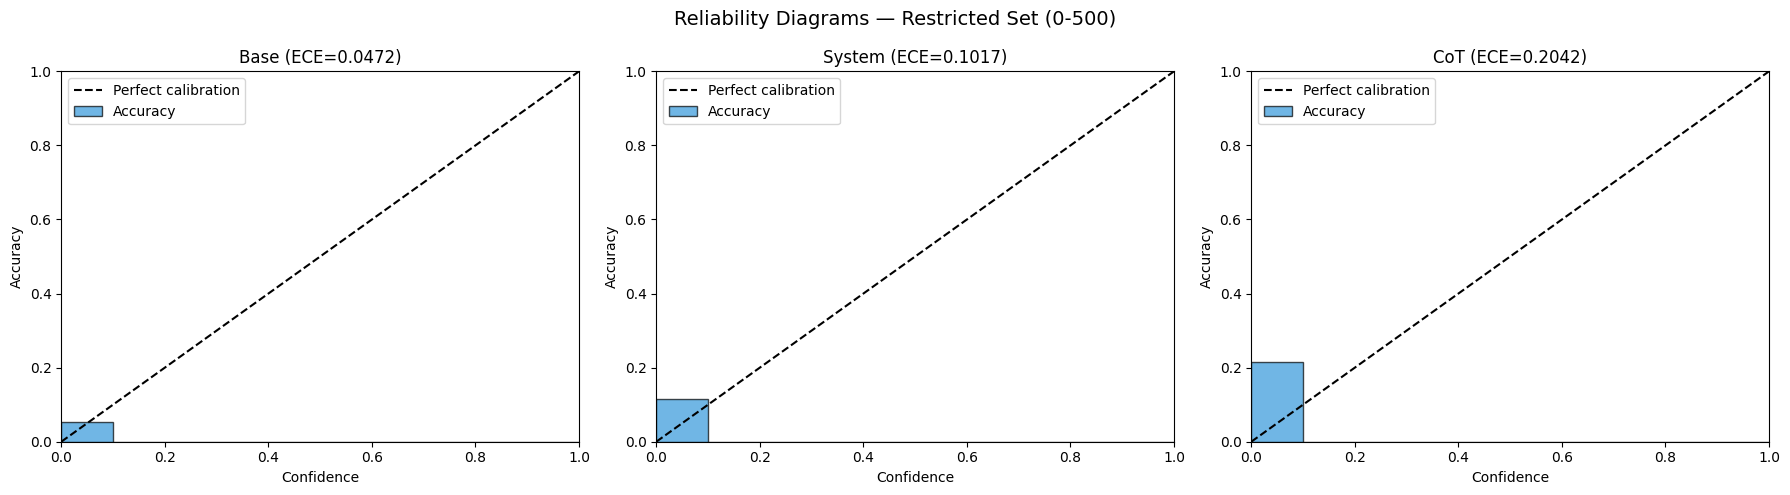


=== ECE Summary ===
Base: Raw ECE = 0.2285, Restricted ECE = 0.0472
System: Raw ECE = 0.3547, Restricted ECE = 0.1017
CoT: Raw ECE = 0.6814, Restricted ECE = 0.2042


In [ ]:
def compute_ece(confidences, corrects, n_bins=10):
    """Compute Expected Calibration Error."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_accs, bin_confs, bin_counts = [], [], []
    
    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i+1]
        mask = (confidences >= lo) & (confidences < hi)
        if mask.sum() == 0:
            bin_accs.append(0)
            bin_confs.append((lo + hi) / 2)
            bin_counts.append(0)
        else:
            bin_accs.append(corrects[mask].mean())
            bin_confs.append(confidences[mask].mean())
            bin_counts.append(mask.sum())
    
    bin_accs = np.array(bin_accs)
    bin_confs = np.array(bin_confs)
    bin_counts = np.array(bin_counts)
    
    ece = np.sum(bin_counts * np.abs(bin_accs - bin_confs)) / np.sum(bin_counts) if np.sum(bin_counts) > 0 else 0
    return ece, bin_accs, bin_confs, bin_counts

N_BINS = 10
n_methods = len(calibration_results)

# Plot both raw and restricted reliability diagrams
for conf_type, conf_key, title_prefix in [
    ("Raw", "raw_confidences", "Raw Token Probability"),
    ("Restricted", "restricted_confidences", "Restricted Set (0-500)")
]:
    fig, axes = plt.subplots(1, n_methods, figsize=(6*n_methods, 5))
    if n_methods == 1:
        axes = [axes]

    for ax, (method_name, res) in zip(axes, calibration_results.items()):
        ece, bin_accs, bin_confs, bin_counts = compute_ece(res[conf_key], res["corrects"], N_BINS)
        
        bin_edges = np.linspace(0, 1, N_BINS + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = 1.0 / N_BINS
        
        ax.bar(bin_centers, bin_accs, width=bin_width, alpha=0.7, color='#3498db', edgecolor='black', label='Accuracy')
        ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
        ax.set_xlabel("Confidence")
        ax.set_ylabel("Accuracy")
        ax.set_title(f"{method_name} (ECE={ece:.4f})")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend()

    plt.suptitle(f"Reliability Diagrams — {title_prefix}", fontsize=14)
    plt.tight_layout()
    plt.show()

print("\n=== ECE Summary ===")
for method_name, res in calibration_results.items():
    raw_ece, _, _, _ = compute_ece(res["raw_confidences"], res["corrects"], N_BINS)
    rest_ece, _, _, _ = compute_ece(res["restricted_confidences"], res["corrects"], N_BINS)
    print(f"{method_name}: Raw ECE = {raw_ece:.4f}, Restricted ECE = {rest_ece:.4f}")


## Analysis

*TODO: Write a short paragraph (4–6 sentences). Are the models overconfident or underconfident? How does ECE compare across methods? Does confidence correlate with correctness?*
